# EDA for carbreakdown data

In deze notebook gaan we de dataset in in train_CarBreakDown onderzoeken. Eerst starten we met een algemeen zicht op de data set via een describe. Dit world gevolgd door null waarde weg te halen want deze zullen de eind resultaten het meest beïnvloeden. Dan kijken we de verdelingen van de data per kollom om te zien als er dingen opvallen. Als laatst kijken we nog voor enige andere eigenaardigheden.

## Obtain data in variabel

Eerst starten we met het inlezen van de data. Hierop voeren we direct een describe uit om een snel overzicht van de data te verkrijgen.

In [421]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# read csv file
df = pd.read_csv('../csv/train/train_CarBreakDown.csv')
print(f"Null value overview:\n{df.isnull().sum()}\n")
print(f"Total nulls in dataset: {df.isnull().sum().sum()}")
print(f"Gemiddelde nulls in dataset: {round(df.isnull().sum().mean())}")

totaal_records = len(df)
print(f"Totaal aantal records {totaal_records}")
df.describe(include='all')


# initial suspicions:
# all collumns are missing values except id (logical) and breakdown _next_30_days which is our goal to calculate
# There negative values in mileage_km, engine_hours and cleanliness_score which should not be possible
# oil_quality is a percentage but max is 102...
# same with cleanliness_score
# maybe driver_satisfaction to

Null value overview:
id                            0
vehicle_brand                21
vehicle_age_years            16
mileage_km                   17
engine_hours                 15
last_service_km_ago          10
oil_quality_pct              36
avg_trip_length_km           12
weather_exposure             13
fuel_type                    14
cleanliness_score            55
driver_satisfaction_score    13
tyre_type                    17
breakdown_next_30_days        0
dtype: int64

Total nulls in dataset: 239
Gemiddelde nulls in dataset: 17
Totaal aantal records 1050


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
count,1050.000000,1029,1034.000000,1.033000e+03,1035.000000,1040.000000,1014.000000,1038.000000,1037,1036,995.000000,1037.000000,1033,1050.000000
unique,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN,4,5,NaN,NaN,4,NaN
top,NaN,Ford,NaN,NaN,NaN,NaN,NaN,NaN,medium,petrol,NaN,NaN,summer,NaN
freq,NaN,194,NaN,NaN,NaN,NaN,NaN,NaN,428,435,NaN,NaN,386,NaN
mean,742.984762,NaN,9.399420,3.639119e+06,4368.929467,10681.075986,60.682779,38.861387,NaN,NaN,69.393768,6.972183,NaN,0.167619
std,430.089010,NaN,5.752228,2.585818e+07,2214.510223,9341.969609,20.298624,47.968702,NaN,NaN,15.570872,1.478278,NaN,0.373706
min,0.000000,NaN,0.000000,-1.829042e+02,-50.000000,10.869020,0.000000,1.011100,NaN,NaN,-13.171570,2.504369,NaN,0.000000
25%,372.250000,NaN,5.000000,8.338616e+04,2773.353090,3374.773323,47.377582,8.187057,NaN,NaN,58.902723,6.001099,NaN,0.000000
50%,740.500000,NaN,9.000000,1.202357e+05,3967.125562,8085.318122,60.528422,16.788852,NaN,NaN,69.504547,6.928004,NaN,0.000000
75%,1109.250000,NaN,14.000000,1.674871e+05,5432.498224,14455.318280,74.654436,44.308719,NaN,NaN,79.597898,8.022503,NaN,0.000000


Uit de bovenstaande analyse is te zien dat 239 waarden over alle kollomen (1050) niet ingevuld is. Dit betekent dat we maximum 23% van de data verliezen, er van uit gaand dat elke null in een verschillend record voorkomt.

We kunnen hier op twee manier mee omgaan, amputatie of imputatie.

**Amputatie**: Het verwijderen van de rij of kollomen die null waarde bevatten om enkel over te blijven met ingevulde records. Dit is ten koste van de grote van de data set.

**Imputatie**: Het vervangen van de data, vaak door het gemiddelde of median om de data volledig te maken. Dit kan enkel als de rest van de gegevens ok zijn en kan de gegevens veralgemene.

 Zelfs als het niet exact 23%, 15% (893 resterend in dat geval) zou ook all veel impact hebben op de resultaten omdat de data set redelijk klein is en het houd ook niet rekening dat er voor nog andere redenen records gedropt kunnen worden. Het is dus het beste om zoveel mogelijk kollomen te imputeren. Dit gaat niet alteid handig zijn zoals bij vehicle brand, hier zal dan amputatie gebruikt worden.

## Per kollom null waarde behandeling

Nu gaan we per kollom af om te kijken wat er aangepast kan worden zoals het droppen/imputeren van null waarde. Er zijn twee soorten kollom in de dataset numerieke en categorische. 

Bij numerieke kollomen wordt er gekeken naar de verdeling van de waarde via een boxplot om te zien als er onwaarscheinlijke uitschieters zijn.

Bij categorische waarde kan dit natuurlijk niet en wordt er via een barchart gekeken hoe de verdeling is tussen categorieën. All deze kollomen hebben een "other" kollom en afhankelijk van de grote hier van kunnen de records hiervan ook gedropt worden omdat deze data niet specifiek is (het is well beter dan null). Dit maakt het bewaren van kollom waar het mogelijk is nog beter want dan kunnen other kollomen makkelijker gedropt worden.

### vehicle_brand

Kollom null waardes: 21 (2.0%)
vehicle_brand
Ford          194
Toyota        193
Volkswagen    143
BMW           125
Hyundai       101
Renault        97
Volvo          93
Kia            69
other          14
Name: count, dtype: int64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,494744.972722,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
2,1304,Hyundai,1.0,188558.432414,6678.958321,11726.320455,25.491428,41.692205,medium,hybrid,47.223966,5.842726,winter,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
5,606,Renault,1.0,209439.442769,7156.897259,3527.010815,52.147399,1.458703,high,hybrid,57.117174,7.676373,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,NaN,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


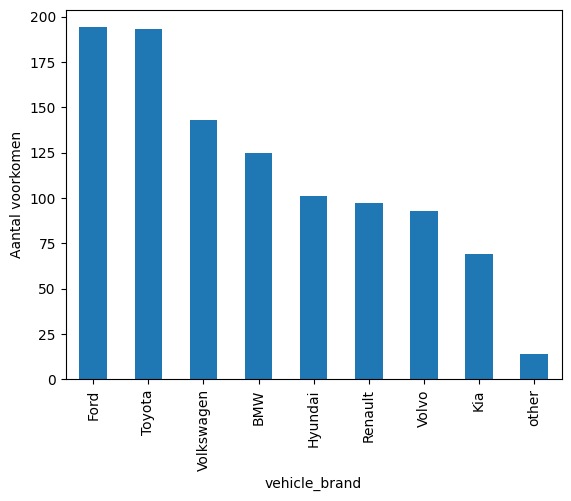

In [422]:
vehicle_brand = df['vehicle_brand']
print(f"Kollom null waardes: {vehicle_brand.isnull().sum()} ({(vehicle_brand.isnull().sum()/totaal_records * 100).round(2)}%)")

print(df.vehicle_brand.value_counts())
df['vehicle_brand'].value_counts().plot(kind='bar',ylabel='Aantal voorkomen')


df.dropna(subset='vehicle_brand', inplace=True) # subset is gebruikt om enkel 1 kollom de records te droppen
df


Vehicle_brand is een **categorische kollom**, hierdoor wordt er zeker **geamputeerd**. Het heeft een boven gemiddeld aantal null waarde maar de gemiddelde category nemen zou niet een goede oplossing zijn want dan wordt deze over gerepresenteerd. De **other waarde blijft** omdat het nog steeds op iets kan duiden => het ontbreken van een groot genoegen category maar is niet onbekend.

Interresant om te zien is dat de verdeling van merken **niet even ligt** en sommige veel meer voorkomen.

Het resultaat is **21 gedropte kollomen**.

### vehicle_age

Kollom snel overzicht: 

Kollom null waardes: 16 (1.52%)
Kollom gemiddelde: 9.385982230997039
Kollom median: 9.0
Kollom uitschieters: 0

Algemene Data Na aanpassing
count    1029.000000
mean        9.379981
std         5.701425
min         0.000000
25%         5.000000
50%         9.000000
75%        14.000000
max        20.000000
Name: vehicle_age_years, dtype: float64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,494744.972722,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
2,1304,Hyundai,1.0,188558.432414,6678.958321,11726.320455,25.491428,41.692205,medium,hybrid,47.223966,5.842726,winter,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
5,606,Renault,1.0,209439.442769,7156.897259,3527.010815,52.147399,1.458703,high,hybrid,57.117174,7.676373,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,NaN,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


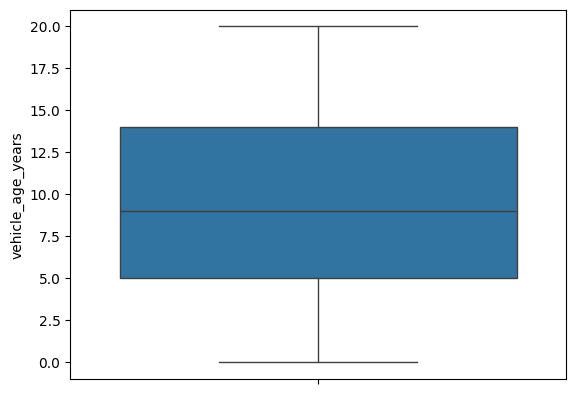

In [423]:
vehicle_age = df['vehicle_age_years']

print("Kollom snel overzicht: \n")
print(f"Kollom null waardes: {vehicle_age.isnull().sum()} ({(vehicle_age.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"Kollom gemiddelde: {vehicle_age.mean()}")
print(f"Kollom median: {vehicle_age.median()}")
print(f"Kollom uitschieters: {len(df[(df['vehicle_age_years'] >df['vehicle_age_years'].mean() + df['vehicle_age_years'].std()*2) | (df['vehicle_age_years'] < df['vehicle_age_years'].mean() - df['vehicle_age_years'].std()*2)])}")

sns.boxplot(data=df, y='vehicle_age_years')

df.fillna({'vehicle_age_years':vehicle_age.mean()},inplace=True) # use dictonairy to specify which collum to change
df['vehicle_age_years'] = df['vehicle_age_years'].round() # round because all other calues are whole numbers

print("\nAlgemene Data Na aanpassing")
print(df['vehicle_age_years'].describe())
df

Vehicle_age_years is een **numerieke kollom**.Het is ook relatief **normaal verdeelt**. Dit betekend dat we niet extra waarden moeten weg halen voor uitschieters en dat we veilig de null waarde kunnen **imputeren**. Deze imputatie wordt gedaan met **ronding** omdat alle waarde gehele getallen zijn.

### mileage_km

Kollom snel overzicht: 

Kollom null waardes: 17 (1.62%)
Kollom gemiddelde: 3712131.6410534824
Kollom median: 120361.01823412706
Kollom uitschieters: 24
Kollom 95% quantile boven aantal: 51
55952801.60350444

Algemene Data Na aanpassing
count       979.000000
mean     124405.596419
std       64051.798832
min         491.692384
25%       78446.349484
50%      113057.424374
75%      157951.333474
max      345189.149108
Name: mileage_km, dtype: float64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,240720.000000,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
6,1362,Volvo,11.0,66541.746883,1436.255252,5158.229238,52.388355,29.987997,medium,diesel,34.610147,4.221209,summer,0
7,285,Toyota,19.0,120040.213061,3799.069247,33057.522511,27.637197,186.883521,medium,diesel,85.933503,6.185589,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,NaN,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


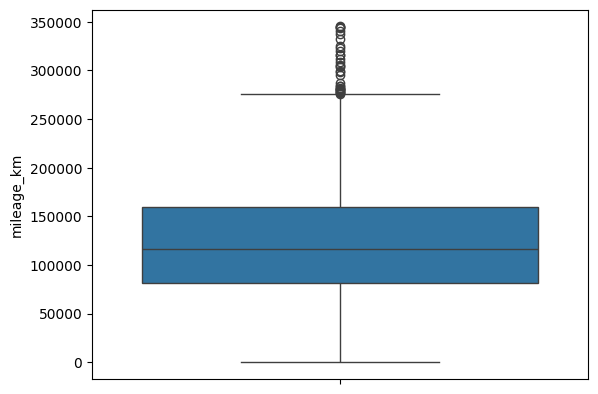

In [424]:
mileage_km = df['mileage_km']

print("Kollom snel overzicht: \n")
print(f"Kollom null waardes: {mileage_km.isnull().sum()} ({(mileage_km.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"Kollom gemiddelde: {mileage_km.mean()}")
print(f"Kollom median: {mileage_km.median()}")
print(f"Kollom uitschieters: {len(df[(df['mileage_km'] >df['mileage_km'].mean() + df['mileage_km'].std()*2) | (df['mileage_km'] < df['mileage_km'].mean() - df['mileage_km'].std()*2)])}")
print(f"Kollom 95% quantile boven aantal: {len(df[df['mileage_km'] > df['mileage_km'].quantile(0.95)])}")

print(df['mileage_km'].mean() + df['mileage_km'].std()*2)
# sns.violinplot(data=df, y='mileage_km')
sns.boxplot(data=df[(df['mileage_km'] < df['mileage_km'].quantile(0.95))], y='mileage_km') 

df.loc[df['mileage_km'] > df['mileage_km'].quantile(0.95), 'mileage_km'] = df.loc[df['mileage_km'] > df['mileage_km'].quantile(0.95), 'vehicle_age_years'] * 12036 # replace values above 95% quantile with there age because if the vehicle is used longer the mileage should be higher, 120361 is the median and most accurate measure because a car driven 10 years has about 120 000 km mileage, assuming there relation is linear we can multiply them, given them an average value and prevent droppping 51 records

df.loc[df['mileage_km'] < 0, 'mileage_km'] = df.loc[df['mileage_km'] < 0, 'vehicle_age_years'] * 12036  # replace negative values with age times median because negative mileage does not exist, and saves 1 record

df.loc[df['mileage_km'].isnull(), 'mileage_km'] = df.loc[df['mileage_km'].isnull(), 'vehicle_age_years'] * 12036  # replace null values with age times median

df = df.drop(df[(df['mileage_km'] > df['mileage_km'].mean()) & (df['vehicle_age_years'] < 3)].index) # drop records which have cars that are les then two years old and have a mileage higher then the mean


print("\nAlgemene Data Na aanpassing")
print(df['mileage_km'].describe())
df

Mileage_km is een **numerieke kollom**. Wanneer je eerst de data bekijkt zie je dat deze kollom een harde right skew heeft. Dit heeft als gevolg dat het gemiddelde een slecht maat is om te gebruiken. De median is hier beter met **120361.02** wat dicht bij ligt bij de waarde van een auto van 10 jaar volgens een snelle zoekopdracht. 

Door de heel extreme skewing in de data gaat zelfs **2 * standaard divatie niet echt betrouwbaar** meer zijn dus ik heb geopteerd om the **95% percentiel** te gebruiken. Alle waarde boven dit worden vervangen door een estimatie van wat het zou moeten zijn **12036 * auto leeftijd** want het gemiddelde is niet betrouwbaar. Het zelfde wordt gedaan met negatieve waarde want deze zouden niet mogelijk zijn en null waarde. 

Hierdoor kunnen we nog steeds zoveel mogelijk data behouden. Toch moeten er records gedropped worden voor niet logische zoals een auto die net nieuw is maar veel heeft gereden dit coste **50 records**.

### engine_hours

Kollom snel overzicht: 

Kollom null waardes: 13 (1.24%)
Kollom gemiddelde: 4294.31822484435
Kollom median: 3849.8382132491315
Kollom uitschieters: 61
Kollom gemiddelde: 4344.357492355646
Kollom median: 3905.2567750627713

Algemene Data Na aanpassing
count      975.000000
mean      4320.482878
std       2125.547772
min        579.571845
25%       2777.785346
50%       3917.359207
75%       5351.652731
max      10298.582128
Name: engine_hours, dtype: float64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,240720.000000,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
6,1362,Volvo,11.0,66541.746883,1436.255252,5158.229238,52.388355,29.987997,medium,diesel,34.610147,4.221209,summer,0
7,285,Toyota,19.0,120040.213061,3799.069247,33057.522511,27.637197,186.883521,medium,diesel,85.933503,6.185589,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,NaN,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


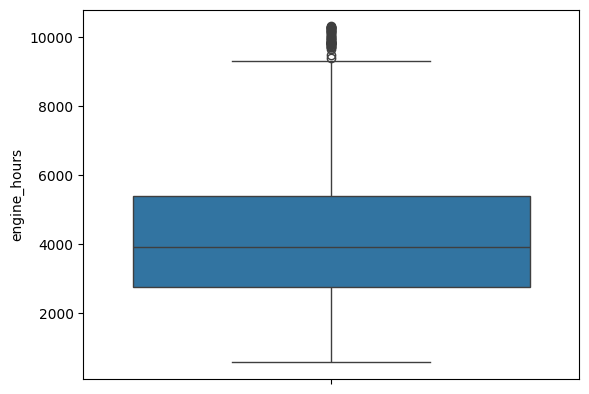

In [425]:
engine_hours = df['engine_hours']

print("Kollom snel overzicht: \n")
print(f"Kollom null waardes: {engine_hours.isnull().sum()} ({(engine_hours.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"Kollom gemiddelde: {engine_hours.mean()}")
print(f"Kollom median: {engine_hours.median()}")
print(f"Kollom uitschieters: {len(df[(df['engine_hours'] >df['engine_hours'].mean() + df['engine_hours'].std()*2) | (df['engine_hours'] < df['engine_hours'].mean() - df['engine_hours'].std()*2)])}")

df.loc[df['engine_hours'] < 0, 'engine_hours'] = df.loc[df['engine_hours'] >= 0, 'engine_hours'].mean() # replace negative values with mean without negatives
print(f"Kollom gemiddelde: {df['engine_hours'].mean()}")
print(f"Kollom median: {df['engine_hours'].median()}")
sns.boxplot(data=df, y='engine_hours')

df.fillna({'engine_hours':engine_hours.mean()},inplace=True) # use dictonairy to specify which collum to change
df = df.fillna({'engine_hours': df['engine_hours'].mean()})
df = df.drop(df[(df['engine_hours'] > 9000) & (df['vehicle_age_years'] < 3)].index) # drop not logical values => having a age of 1 with 8500 + engine hours (.index gives the index of where the condition is true)

print("\nAlgemene Data Na aanpassing")
print(df['engine_hours'].describe())
df

Engine_hours is een **numerieke kollom**. Deze kollom is **vergelijkbaar met de milleage_km kollom** maar zonder de skew. Het meest op opvallend is de **11 negatieve waarde** in de kollom wat normaal gezien niet mogelijk zou moeten zijn. Deze worden dan naar het **gemiddelden gezet** (zonder hun meegerekend) samen met de null waardes.

Deze kollom heeft een paar records die ook onlogisch kunnen zijn. Dit koste **4 records**

### last_service_km_ago

Kollom snel overzicht: 

Kollom null waardes: 9 (0.86%)
Kollom gemiddelde: 10790.880439433151
Kollom median: 8125.877494596188
Kollom uitschieters: 52

Algemene Data Na aanpassing
count      957.000000
mean     10761.479657
std       9330.043325
min         10.869020
25%       3494.927437
50%       8320.267400
75%      14505.830784
max      40592.195120
Name: last_service_km_ago, dtype: float64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,240720.000000,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
6,1362,Volvo,11.0,66541.746883,1436.255252,5158.229238,52.388355,29.987997,medium,diesel,34.610147,4.221209,summer,0
7,285,Toyota,19.0,120040.213061,3799.069247,33057.522511,27.637197,186.883521,medium,diesel,85.933503,6.185589,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,NaN,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


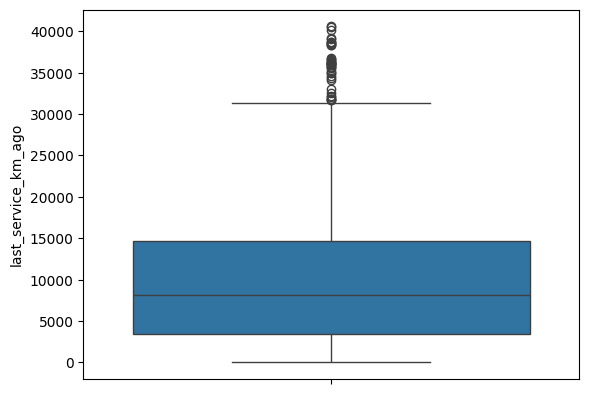

In [426]:
last_service_km_ago = df['last_service_km_ago']

print("Kollom snel overzicht: \n")
print(f"Kollom null waardes: {last_service_km_ago.isnull().sum()} ({(last_service_km_ago.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"Kollom gemiddelde: {last_service_km_ago.mean()}")
print(f"Kollom median: {last_service_km_ago.median()}")
print(f"Kollom uitschieters: {len(df[(df['last_service_km_ago'] >df['last_service_km_ago'].mean() + df['last_service_km_ago'].std()*2) | (df['last_service_km_ago'] < df['last_service_km_ago'].mean() - df['last_service_km_ago'].std()*2)])}")

sns.boxplot(data=df, y='last_service_km_ago')

df.fillna({'last_service_km_ago': last_service_km_ago.mean()},inplace=True) # use dictonairy to specify which collum to change

df = df.drop(df[df['last_service_km_ago'] > df['mileage_km']].index) # drop not logical values => last service cannot be higher then the mileage of the car because to have distance between services the car also gets milleage

print("\nAlgemene Data Na aanpassing")
print(df['last_service_km_ago'].describe())
df

Last_service_km_ago is een **numerieke kollom**. Het is een redelijk simpele kollom het is right skewed maar is nog steeds logisch **40592.195120km** rijden is nog steeds mogelijk, enkel onwaarschijnlijk. Via een snelle zoekopdracht vindt je dat **15 000km het gemiddelde is tussen service controles** wat opvallend hoger ligt dan dit gemiddelde van de kollom. Dit komt vast omdat de kollom aanduid wanneer de test voor crash gebeurt is waardoor het logisch is dat het gemiddelde lager ligt.

Er worden well nog wat records gedropt. Als de milleage_km kleiner is dan de last_service_km_ago dan is er iets fout. Dit koste **18 records**.

### oil_quality_pct

Kollom snel overzicht: 

Kollom null waardes: 33 (3.14%)
Kollom gemiddelde: 60.864621066253086
Kollom median: 60.68414702168123
Kollom uitschieters: 22

Algemene Data Na aanpassing
count    957.000000
mean      60.402949
std       19.511108
min        0.000000
25%       47.834134
50%       60.864621
75%       73.423653
max      100.000000
Name: oil_quality_pct, dtype: float64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,240720.000000,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
6,1362,Volvo,11.0,66541.746883,1436.255252,5158.229238,52.388355,29.987997,medium,diesel,34.610147,4.221209,summer,0
7,285,Toyota,19.0,120040.213061,3799.069247,33057.522511,27.637197,186.883521,medium,diesel,85.933503,6.185589,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,60.864621,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


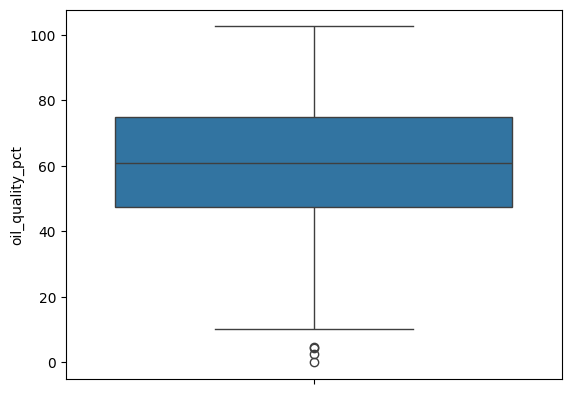

In [427]:
oil_quality_pct = df['oil_quality_pct']

print("Kollom snel overzicht: \n")
print(f"Kollom null waardes: {oil_quality_pct.isnull().sum()} ({(oil_quality_pct.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"Kollom gemiddelde: {oil_quality_pct.mean()}")
print(f"Kollom median: {oil_quality_pct.median()}")
print(f"Kollom uitschieters: {len(df[(df['oil_quality_pct'] >df['oil_quality_pct'].mean() + df['oil_quality_pct'].std()*2) | (df['oil_quality_pct'] < df['oil_quality_pct'].mean() - df['oil_quality_pct'].std()*2)])}")

sns.boxplot(data=df, y='oil_quality_pct')

df.fillna({'oil_quality_pct': oil_quality_pct.mean()},inplace=True) # use dictonairy to specify which collum to change

df.loc[df['oil_quality_pct'] > 100, 'oil_quality_pct'] = df['oil_quality_pct'].mean() # this collum is a percentage and cannot be higherthen 100, replace it with mean

print("\nAlgemene Data Na aanpassing")
print(df['oil_quality_pct'].describe())
df

Oil_quality_pct is een **numerieke kollom en een percentage**. Het is **heel normaal verdeelt** en zijn er weinig uitschieters. Hier wordt ook weer zoals alteid de null waarde door het gemiddelde vervangen.

Voor logische percentages te hebben werden de **percentages goter naar honderd naar het gemiddelde** gezet.

### avg_trip_length_km

Kollom snel overzicht: 

Kollom null waardes: 11 (1.05%)
Kollom gemiddelde: 39.597938206149514
Kollom median: 17.464734680300662
Kollom uitschieters: 74

Algemene Data Na aanpassing
count    957.000000
mean      39.597938
std       48.195694
min        1.011100
25%        8.426205
50%       17.887635
75%       45.046368
max      201.015553
Name: avg_trip_length_km, dtype: float64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,240720.000000,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
6,1362,Volvo,11.0,66541.746883,1436.255252,5158.229238,52.388355,29.987997,medium,diesel,34.610147,4.221209,summer,0
7,285,Toyota,19.0,120040.213061,3799.069247,33057.522511,27.637197,186.883521,medium,diesel,85.933503,6.185589,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,60.864621,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


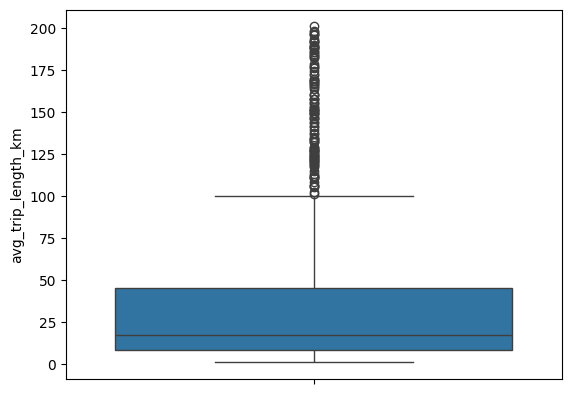

In [428]:
avg_trip_length_km = df['avg_trip_length_km']

print("Kollom snel overzicht: \n")
print(f"Kollom null waardes: {avg_trip_length_km.isnull().sum()} ({(avg_trip_length_km.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"Kollom gemiddelde: {avg_trip_length_km.mean()}")
print(f"Kollom median: {avg_trip_length_km.median()}")
print(f"Kollom uitschieters: {len(df[(df['avg_trip_length_km'] >df['avg_trip_length_km'].mean() + df['avg_trip_length_km'].std()*2) | (df['avg_trip_length_km'] < df['avg_trip_length_km'].mean() - df['avg_trip_length_km'].std()*2)])}")

sns.boxplot(data=df, y='avg_trip_length_km')

df.fillna({'avg_trip_length_km': avg_trip_length_km.mean()},inplace=True) # use dictonairy to specify which collum to change

df.loc[df['avg_trip_length_km'] < 0, 'avg_trip_length_km'] = df['avg_trip_length_km'].median() # this collum is a distance and cannot be negative, replace it with mean

print("\nAlgemene Data Na aanpassing")
print(df['avg_trip_length_km'].describe())
df

Avg_trip_length_km is een **numerieke kollom**. Het is **redelijk rechtsgeskewed** te zien aan de boxplot. De waarde die er aanwezig zijn, zijn redelijk reël waardoor **niets aan de data moet aangepast worden** behalve de **null waarde vervangen met de median** want gemiddelde is minder betrouwbaar.

### weather_exposure

Kollom null waardes: 12 (1.14%)
weather_exposure
medium    391
low       350
high      185
other      19
Name: count, dtype: int64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,240720.000000,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
6,1362,Volvo,11.0,66541.746883,1436.255252,5158.229238,52.388355,29.987997,medium,diesel,34.610147,4.221209,summer,0
7,285,Toyota,19.0,120040.213061,3799.069247,33057.522511,27.637197,186.883521,medium,diesel,85.933503,6.185589,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,60.864621,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


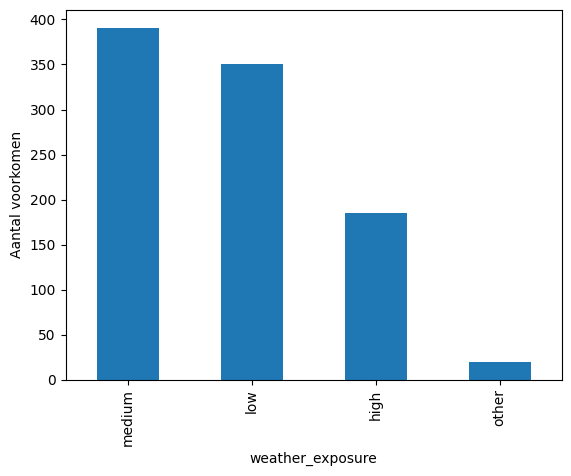

In [429]:
weather_exposure= df['weather_exposure']
print(f"Kollom null waardes: {weather_exposure.isnull().sum()} ({(weather_exposure.isnull().sum()/totaal_records * 100).round(2)}%)")

print(df.weather_exposure.value_counts())
df['weather_exposure'].value_counts().plot(kind='bar',ylabel='Aantal voorkomen')


df.dropna(subset='weather_exposure', inplace=True) # subset is gebruikt om enkel 1 kollom de records te droppen
df

Weather_exposure is een **categorische kollom**. Dit volgt dezelfde logica als bij vehicle_brand waar we the null waarde droppen **ten koste van 12 records** en behouden de other waarden om niet de grootste waarde over te representeren.

In de data set komt medium weer verstoring het meest voor.

### fuel_type

Kollom null waardes: 14 (1.33%)
fuel_type
petrol      382
diesel      336
hybrid      142
electric     52
other        19
Name: count, dtype: int64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,240720.000000,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
6,1362,Volvo,11.0,66541.746883,1436.255252,5158.229238,52.388355,29.987997,medium,diesel,34.610147,4.221209,summer,0
7,285,Toyota,19.0,120040.213061,3799.069247,33057.522511,27.637197,186.883521,medium,diesel,85.933503,6.185589,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,60.864621,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


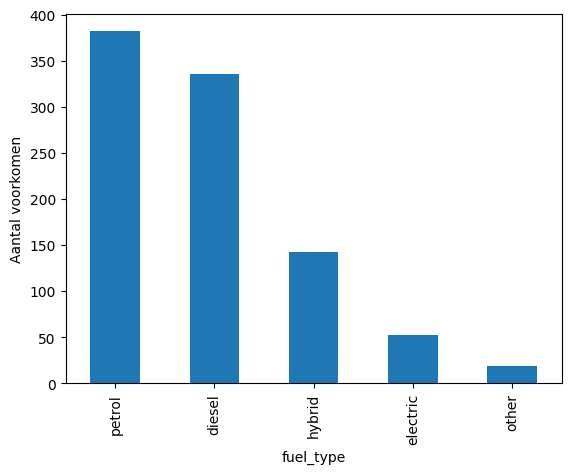

In [430]:
fuel_type= df['fuel_type']
print(f"Kollom null waardes: {fuel_type.isnull().sum()} ({(fuel_type.isnull().sum()/totaal_records * 100).round(2)}%)")

print(df.fuel_type.value_counts())
df['fuel_type'].value_counts().plot(kind='bar',ylabel='Aantal voorkomen')


df.dropna(subset='fuel_type', inplace=True) # subset is gebruikt om enkel 1 kollom de records te droppen
df

Fuel_type is een **catigorische kollom**. Net zoals de andere worden de **null waarden gedropt met 14 records** in totaal. De other kollom blijft ook weer behouden om niet een andere kollom te iver representeren.

De grootste aantal auto's gebruiken in de dataset fosiele brandstof.

### cleanliness_score

Kollom snel overzicht: 

Kollom null waardes: 47 (4.48%)
Kollom gemiddelde: 69.56423412859205
Kollom median: 69.62991411892966
Kollom uitschieters: 28

Algemene Data Na aanpassing
count    931.000000
mean      68.819186
std       13.660236
min       18.840529
25%       59.883096
50%       69.564234
75%       78.339988
max       99.678105
Name: cleanliness_score, dtype: float64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,240720.000000,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
6,1362,Volvo,11.0,66541.746883,1436.255252,5158.229238,52.388355,29.987997,medium,diesel,34.610147,4.221209,summer,0
7,285,Toyota,19.0,120040.213061,3799.069247,33057.522511,27.637197,186.883521,medium,diesel,85.933503,6.185589,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,60.864621,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


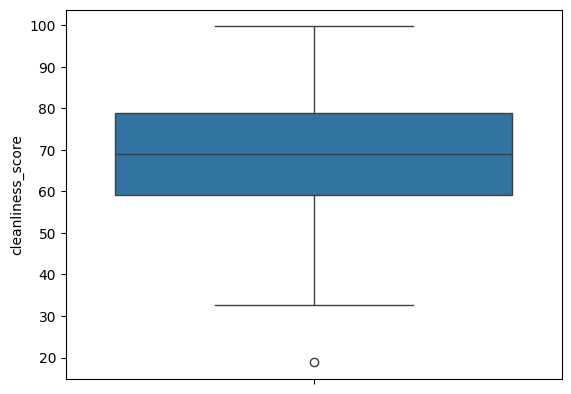

In [431]:
cleanliness_score = df['cleanliness_score']

print("Kollom snel overzicht: \n")
print(f"Kollom null waardes: {cleanliness_score.isnull().sum()} ({(cleanliness_score.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"Kollom gemiddelde: {cleanliness_score.mean()}")
print(f"Kollom median: {cleanliness_score.median()}")
print(f"Kollom uitschieters: {len(df[(df['cleanliness_score'] >df['cleanliness_score'].mean() + df['cleanliness_score'].std()*2) | (df['cleanliness_score'] < df['cleanliness_score'].mean() - df['cleanliness_score'].std()*2)])}")

df.loc[df['cleanliness_score'] < 0,'cleanliness_score'] = df.loc[df['cleanliness_score'] > 0,'cleanliness_score'].mean() # replace the 1 negative value with the mean
df.loc[df['cleanliness_score'] > 100,'cleanliness_score'] = df.loc[df['cleanliness_score'] < 100,'cleanliness_score'].mean() # cleanliness_score has a range to 100 and cannot be higher so replace those with the mean
sns.boxplot(data=df, y='cleanliness_score')


df.fillna({'cleanliness_score': cleanliness_score.mean()},inplace=True) # use dictonairy to specify which collum to change


print("\nAlgemene Data Na aanpassing")
print(df['cleanliness_score'].describe())
df

Cleanliness_score is een **numerique kollom**.  Het is **normaal verdeelt** en opvallend **veel null waarde**. Hier kunnen deze waarde weer door het gemiddelde vervangen worden.

De cleanliness_score is een **waarde tussen 0 en 100**. Andere waarde moeten vervangen/gedropt worden. Net zoals alteid worden ze **vervangen** door het gemiddelde om de data te behouden.

### driver_satisfaction_score

Kollom snel overzicht: 

Kollom null waardes: 12 (1.14%)
Kollom gemiddelde: 6.954378170420557
Kollom median: 6.883715501680923
Kollom uitschieters: 36

Algemene Data Na aanpassing
count    931.000000
mean       6.891600
std        1.410334
min        2.504369
25%        5.942814
50%        6.890780
75%        7.897841
max        9.984313
Name: driver_satisfaction_score, dtype: float64


,id,vehicle_brand,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type,breakdown_next_30_days
0,959,Toyota,20.0,240720.000000,9700.481467,1672.048445,61.664556,30.362090,high,petrol,68.117833,8.559011,NaN,0
1,804,Toyota,0.0,38376.684834,1650.726428,21.269170,23.370666,2.500801,high,hybrid,69.294736,9.838274,NaN,0
3,268,Toyota,5.0,92828.113285,2986.923461,1845.744691,54.060416,6.464345,high,diesel,72.246829,4.719607,winter,0
6,1362,Volvo,11.0,66541.746883,1436.255252,5158.229238,52.388355,29.987997,medium,diesel,34.610147,4.221209,summer,0
7,285,Toyota,19.0,120040.213061,3799.069247,33057.522511,27.637197,186.883521,medium,diesel,85.933503,6.185589,summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,562,Renault,6.0,131602.464358,4586.327861,32185.769120,83.247676,6.448159,low,electric,94.249149,6.142659,all-season,0
1046,993,Toyota,9.0,127224.810750,4106.036923,23433.319506,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer,1
1047,245,Ford,19.0,74204.367905,2323.811128,6490.998514,60.864621,39.444093,low,diesel,88.354147,5.944547,winter,0
1048,883,BMW,10.0,198492.993706,6643.176908,3564.136473,82.555275,9.060255,low,diesel,64.073009,6.061162,all-season,0


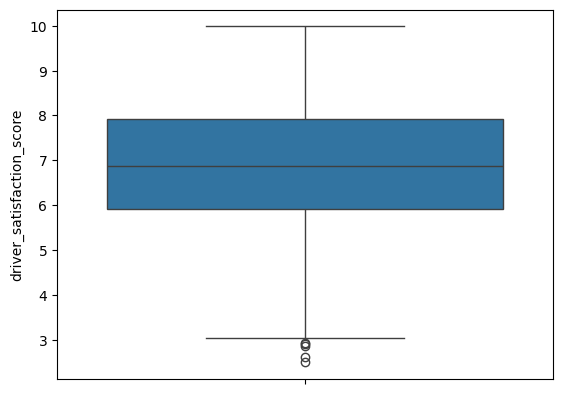

In [ ]:
driver_satifaction_score = df['driver_satisfaction_score']

print("Kollom snel overzicht: \n")
print(f"Kollom null waardes: {driver_satifaction_score.isnull().sum()} ({(driver_satifaction_score.isnull().sum()/totaal_records * 100).round(2)}%)")
print(f"Kollom gemiddelde: {driver_satifaction_score.mean()}")
print(f"Kollom median: {driver_satifaction_score.median()}")
print(f"Kollom uitschieters: {len(df[(df['driver_satisfaction_score'] >df['driver_satisfaction_score'].mean() + df['driver_satisfaction_score'].std()*2) | (df['driver_satisfaction_score'] < df['driver_satisfaction_score'].mean() - df['driver_satisfaction_score'].std()*2)])}")

df.loc[df['driver_satisfaction_score'] > 10,'driver_satisfaction_score'] = df.loc[df['driver_satisfaction_score'] < 10,'driver_satisfaction_score'].mean() # driver_satisfaction_score has a range from 1 to 10 and cannot be higher so replace those with the mean
sns.boxplot(data=df, y='driver_satisfaction_score')


df.fillna({'driver_satisfaction_score': driver_satifaction_score.mean()},inplace=True) # use dictonairy to specify which collum to change


print("\nAlgemene Data Na aanpassing")
print(df['driver_satisfaction_score'].describe())
df

Driver_satisfaction_score is een **numerieke kollom**. Het is **redelijk normaal verdeelt** met enkele uitzonderingen die redelijk normaal zijn bij een score zoals dit. De null waarde worden zoals alteid door het **gemiddelde vervangen**.

De score heeft een **range van 0-10** enkele waarden zijn hoger en moeten ook vervangen worden